In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.model_selection import GridSearchCV

In [7]:
from google.colab import files

uploaded = files.upload()

Saving communities.data to communities.data


In [8]:
columns = [
    'state', 'county', 'community', 'communityname', 'fold',
    'population', 'householdsize', 'racepctblack', 'racePctWhite',
    'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29',
    'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome',
    'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec',
    'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc',
    'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap',
    'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov',
    'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed',
    'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu',
    'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr',
    'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
    'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par',
    'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg',
    'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8',
    'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5',
    'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly',
    'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
    'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous',
    'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR',
    'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc',
    'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt',
    'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart',
    'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian',
    'RentHighQ', 'MedRent', 'MedRentPctHousInc',
    'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters',
    'NumStreet', 'PctForeignBorn', 'PctBornSameState',
    'PctSameHouse85', 'PctSameCity85', 'PctSameState85',
    'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps',
    'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop',
    'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol',
    'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
    'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
    'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 'PopDens',
    'PctUsePubTrans', 'PolicCars', 'PolicOperBudg',
    'LemasPctPolicOnPatr', 'LemasGangUnitDeploy',
    'LemasPctOfficDrugUn', 'PolicBudgPerPop',
    'ViolentCrimesPerPop'
]
df = pd.read_csv(
    '/content/communities.data',
    header=None,
    names=columns,
    na_values='?'
)

df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [9]:
# Target variable
target = 'ViolentCrimesPerPop'

# Remove non-predictive columns
non_predictive = [
    'state',
    'county',
    'community',
    'communityname',
    'fold'
]

# Remove rows where target is missing
df_model = df.dropna(subset=[target]).copy()

# Features and target
X = df_model.drop(columns=non_predictive + [target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1994, 122)
y shape: (1994,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1595, 122)
Testing set : (399, 122)


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values in X_train:",
      X_train_imputed.isnull().sum().sum())

print("Missing values in X_test:",
      X_test_imputed.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


# Decision Tree Regressor

Decision Tree Regressor is a tree-based supervised learning algorithm used to predict a continuous target variable. It recursively splits the dataset based on feature values to create groups with similar target values.

For this project, a Decision Tree Regressor is trained to predict `ViolentCrimesPerPop`. The model is evaluated using R², RMSE, and MAE.

The `max_depth` hyperparameter is tuned using GridSearchCV with 5-fold cross-validation. Tuning the maximum depth helps control the complexity of the tree and can reduce overfitting.

Feature importance is also extracted from the trained tree to identify the features that contribute most to the predictions.

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [13]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train_imputed, y_train)

# Predictions
dt_pred = dt_model.predict(X_test_imputed)

# Evaluation
dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)

print("Decision Tree Regressor")
print("----------------------")
print("R²   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

Decision Tree Regressor
----------------------
R²   : 0.2317273479673081
RMSE : 0.19182542188459537
MAE  : 0.12110275689223056


Hyperparameter Tuning:
The `max_depth` parameter controls the maximum depth of the decision tree. Several values are tested using 5-fold cross-validation, and the value producing the highest cross-validated R² is selected.

In [14]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train_imputed, y_train)

print("Best max_depth:", dt_grid.best_params_['max_depth'])
print("Best CV R²:", dt_grid.best_score_)

Best max_depth: 3
Best CV R²: 0.5419123604051036


In [15]:
# Best Decision Tree model
dt_best = dt_grid.best_estimator_

# Predictions
dt_best_pred = dt_best.predict(X_test_imputed)

# Metrics
dt_best_r2 = r2_score(y_test, dt_best_pred)
dt_best_rmse = np.sqrt(mean_squared_error(y_test, dt_best_pred))
dt_best_mae = mean_absolute_error(y_test, dt_best_pred)

print("Tuned Decision Tree Regressor")
print("-----------------------------")
print("Best Parameters:", dt_grid.best_params_)
print("R²   :", dt_best_r2)
print("RMSE :", dt_best_rmse)
print("MAE  :", dt_best_mae)

Tuned Decision Tree Regressor
-----------------------------
Best Parameters: {'max_depth': 3}
R²   : 0.5417398954152378
RMSE : 0.1481509702200737
MAE  : 0.10257362031016551


Feature importance indicates the relative contribution of each feature to the predictions made by the Decision Tree Regressor. The 15 most important features are visualized below.

In [16]:
# Feature importance
feature_importance = pd.Series(
    dt_best.feature_importances_,
    index=X_train_imputed.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
PctIlleg         0.680735
PctKids2Par      0.106852
PctFam2Par       0.094059
NumStreet        0.038907
racePctWhite     0.038061
NumIlleg         0.034678
racePctHisp      0.006707
householdsize    0.000000
racepctblack     0.000000
population       0.000000
numbUrban        0.000000
pctUrban         0.000000
medIncome        0.000000
pctWWage         0.000000
pctWFarmSelf     0.000000
dtype: float64


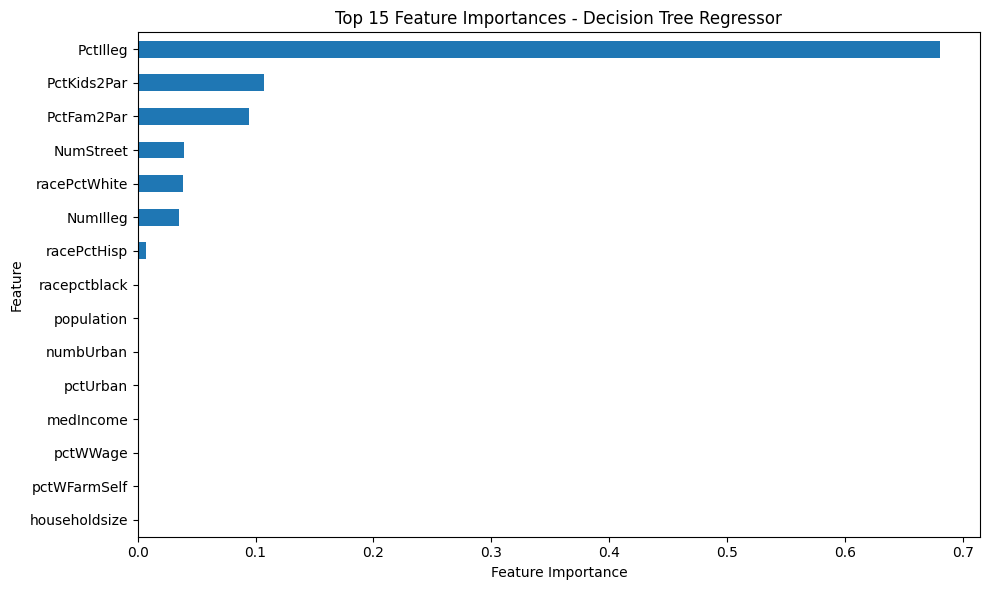

In [17]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind='barh'
)

plt.title("Top 15 Feature Importances - Decision Tree Regressor")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [18]:
dt_result = {
    'Algorithm': 'Decision Tree Regressor',
    'R2': dt_best_r2,
    'RMSE': dt_best_rmse,
    'MAE': dt_best_mae
}

print(dt_result)

{'Algorithm': 'Decision Tree Regressor', 'R2': 0.5417398954152378, 'RMSE': np.float64(0.1481509702200737), 'MAE': 0.10257362031016551}


# Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to make predictions. Each tree is trained using a different sample of the training data and a subset of features, and their predictions are combined to produce the final regression output.

For this project, Random Forest Regressor is used to predict `ViolentCrimesPerPop`. The model is evaluated using R², RMSE, and MAE.

The `n_estimators` hyperparameter is tuned using GridSearchCV with 5-fold cross-validation. This parameter represents the number of decision trees in the forest.

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_imputed, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test_imputed)

# Calculate metrics
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor")
print("----------------------")
print("R²   :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)

Random Forest Regressor
----------------------
R²   : 0.6149651633665181
RMSE : 0.13579959895999044
MAE  : 0.0927749373433584


Hyperparameter Tuning: The `n_estimators` parameter determines the number of trees used in the Random Forest. Different values are tested using 5-fold cross-validation, and the value giving the highest cross-validated R² is selected.

In [20]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [50, 100, 150, 200]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_imputed, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)

Best Parameters: {'n_estimators': 200}
Best CV R²: 0.6467973941065235


In [21]:
# Get the best Random Forest model
rf_best = rf_grid.best_estimator_

# Predictions using the tuned model
rf_best_pred = rf_best.predict(X_test_imputed)

# Calculate metrics
rf_best_r2 = r2_score(y_test, rf_best_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)

print("Tuned Random Forest Regressor")
print("-----------------------------")
print("Best Parameters:", rf_grid.best_params_)
print("R²   :", rf_best_r2)
print("RMSE :", rf_best_rmse)
print("MAE  :", rf_best_mae)

Tuned Random Forest Regressor
-----------------------------
Best Parameters: {'n_estimators': 200}
R²   : 0.6185747846535659
RMSE : 0.13516155359485713
MAE  : 0.09278533834586465


Feature Importance: andom Forest can estimate the importance of each feature based on its contribution across the ensemble of decision trees. The most important features are visualized below.

In [22]:
rf_feature_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train_imputed.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(rf_feature_importance.head(15))

Top 15 Important Features:
PctIlleg            0.318090
PctKids2Par         0.219397
racePctWhite        0.028344
PctFam2Par          0.022351
NumIlleg            0.015671
FemalePctDiv        0.011929
MalePctDivorce      0.011176
NumStreet           0.011148
PctPersDenseHous    0.011113
AsianPerCap         0.010138
HousVacant          0.010133
TotalPctDiv         0.009306
PctHousLess3BR      0.008004
PctUsePubTrans      0.007991
pctWInvInc          0.007858
dtype: float64


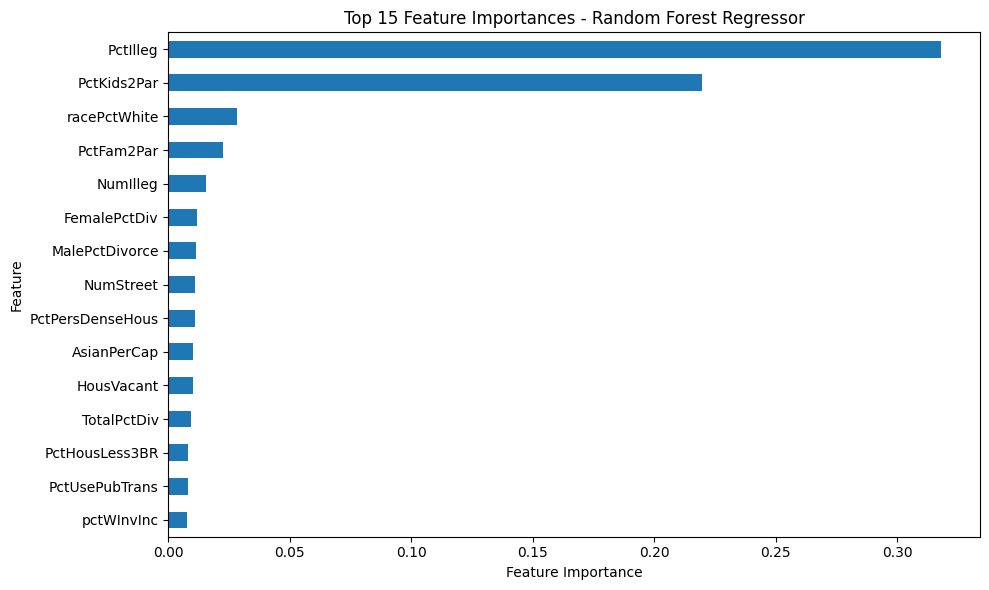

In [23]:
plt.figure(figsize=(10, 6))

rf_feature_importance.head(15).sort_values().plot(
    kind='barh'
)

plt.title("Top 15 Feature Importances - Random Forest Regressor")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [24]:
rf_result = {
    'Algorithm': 'Random Forest Regressor',
    'R2': rf_best_r2,
    'RMSE': rf_best_rmse,
    'MAE': rf_best_mae
}

print(rf_result)

{'Algorithm': 'Random Forest Regressor', 'R2': 0.6185747846535659, 'RMSE': np.float64(0.13516155359485713), 'MAE': 0.09278533834586465}


# Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds decision trees sequentially. Each new tree is trained to improve the predictions made by the previous trees by focusing on the remaining prediction errors.

For this project, Gradient Boosting Regressor is used to predict `ViolentCrimesPerPop`. The model is evaluated using R², RMSE, and MAE.

The `learning_rate` hyperparameter is tuned using GridSearchCV with 5-fold cross-validation. The learning rate controls the contribution of each individual tree to the overall model.

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    random_state=42
)

# Train the model
gb_model.fit(X_train_imputed, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test_imputed)

# Calculate metrics
gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("--------------------------")
print("R²   :", gb_r2)
print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)

Gradient Boosting Regressor
--------------------------
R²   : 0.5982294188812178
RMSE : 0.13871950857579893
MAE  : 0.09187263184958892


Hyperparameter Tuning: The `learning_rate` parameter controls how strongly each new tree contributes to the model. Several learning-rate values are tested using 5-fold cross-validation, and the value producing the highest cross-validated R² is selected.

In [26]:
from sklearn.model_selection import GridSearchCV

gb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(X_train_imputed, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.05}
Best CV R²: 0.6534982089814183


In [27]:
# Get the best Gradient Boosting model
gb_best = gb_grid.best_estimator_

# Predictions
gb_best_pred = gb_best.predict(X_test_imputed)

# Metrics
gb_best_r2 = r2_score(y_test, gb_best_pred)
gb_best_rmse = np.sqrt(mean_squared_error(y_test, gb_best_pred))
gb_best_mae = mean_absolute_error(y_test, gb_best_pred)

print("Tuned Gradient Boosting Regressor")
print("---------------------------------")
print("Best Parameters:", gb_grid.best_params_)
print("R²   :", gb_best_r2)
print("RMSE :", gb_best_rmse)
print("MAE  :", gb_best_mae)

Tuned Gradient Boosting Regressor
---------------------------------
Best Parameters: {'learning_rate': 0.05}
R²   : 0.6054150296045833
RMSE : 0.13747342240259908
MAE  : 0.0924225086141779


In [28]:
gb_result = {
    'Algorithm': 'Gradient Boosting Regressor',
    'R2': gb_best_r2,
    'RMSE': gb_best_rmse,
    'MAE': gb_best_mae
}

print(gb_result)

{'Algorithm': 'Gradient Boosting Regressor', 'R2': 0.6054150296045833, 'RMSE': np.float64(0.13747342240259908), 'MAE': 0.0924225086141779}


# Support Vector Regressor (SVR)

Support Vector Regressor (SVR) is a supervised learning algorithm that extends Support Vector Machine principles to regression problems. It attempts to find a function that predicts continuous values while allowing a specified margin of error.

For this project, SVR is used to predict `ViolentCrimesPerPop`.

Since SVR is sensitive to the scale of input features, StandardScaler is applied before training. The scaler is fitted only on the training data and then applied to both the training and test data to avoid data leakage.

The model is evaluated using R², RMSE, and MAE. The `C` and `kernel` hyperparameters are tuned using GridSearchCV with 5-fold cross-validation.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test_imputed)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Training data shape: (1595, 122)
Testing data shape : (399, 122)


The features have different numerical ranges. StandardScaler is therefore used to standardize the input features before applying SVR.

The scaler is fitted only on the training set and the same transformation is applied to the test set.

In [30]:
from sklearn.svm import SVR

# Support Vector Regressor
svr_model = SVR(
    C=1.0,
    kernel='rbf'
)

# Train
svr_model.fit(X_train_scaled, y_train)

# Predictions
svr_pred = svr_model.predict(X_test_scaled)

# Metrics
svr_r2 = r2_score(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae = mean_absolute_error(y_test, svr_pred)

print("Support Vector Regressor")
print("------------------------")
print("R²   :", svr_r2)
print("RMSE :", svr_rmse)
print("MAE  :", svr_mae)

Support Vector Regressor
------------------------
R²   : 0.5684640361571234
RMSE : 0.14376625924197117
MAE  : 0.10286608953692634


The `C` and `kernel` parameters are tuned using GridSearchCV with 5-fold cross-validation.

The `C` parameter controls the penalty associated with prediction errors, while the `kernel` determines the type of function used to model the relationship between the input features and the target.

In [35]:
svr_param_grid = {
    'C': [1, 10, 100],
    'kernel': ['linear', 'rbf']
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svr_grid.best_params_)
print("Best CV R²:", svr_grid.best_score_)

Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best CV R²: 0.5981908135542946


In [36]:
# Best SVR model
svr_best = svr_grid.best_estimator_

# Predictions
svr_best_pred = svr_best.predict(X_test_scaled)

# Metrics
svr_best_r2 = r2_score(y_test, svr_best_pred)
svr_best_rmse = np.sqrt(mean_squared_error(y_test, svr_best_pred))
svr_best_mae = mean_absolute_error(y_test, svr_best_pred)

print("Tuned Support Vector Regressor")
print("------------------------------")
print("Best Parameters:", svr_grid.best_params_)
print("R²   :", svr_best_r2)
print("RMSE :", svr_best_rmse)
print("MAE  :", svr_best_mae)

Tuned Support Vector Regressor
------------------------------
Best Parameters: {'C': 1, 'kernel': 'rbf'}
R²   : 0.5684640361571234
RMSE : 0.14376625924197117
MAE  : 0.10286608953692634


In [37]:
svr_result = {
    'Algorithm': 'Support Vector Regressor',
    'R2': svr_best_r2,
    'RMSE': svr_best_rmse,
    'MAE': svr_best_mae
}

print(svr_result)

{'Algorithm': 'Support Vector Regressor', 'R2': 0.5684640361571234, 'RMSE': np.float64(0.14376625924197117), 'MAE': 0.10286608953692634}


# K-Nearest Neighbors Regressor (KNN)  

K-Nearest Neighbors (KNN) Regressor is a supervised learning algorithm that predicts the target value of a new observation based on the target values of its nearest training observations.

For this project, KNN Regressor is used to predict `ViolentCrimesPerPop`. The model is evaluated using R², RMSE, and MAE.

KNN is a distance-based algorithm, so feature scaling is important when the input features have different numerical ranges. The standardized training and test data are therefore used for the model.

The `n_neighbors` parameter, which represents the value of k, is tuned using GridSearchCV with 5-fold cross-validation.

In [38]:
from sklearn.neighbors import KNeighborsRegressor

# K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test_scaled)

# Calculate metrics
knn_r2 = r2_score(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_mae = mean_absolute_error(y_test, knn_pred)

print("K-Nearest Neighbors Regressor")
print("----------------------------")
print("R²   :", knn_r2)
print("RMSE :", knn_rmse)
print("MAE  :", knn_mae)

K-Nearest Neighbors Regressor
----------------------------
R²   : 0.5667210159439201
RMSE : 0.14405631034903832
MAE  : 0.09687218045112782


KNN determines neighboring observations using distance calculations. If features have very different scales, features with larger numerical values can have a greater influence on the distance.

Therefore, StandardScaler is used before applying KNN. The scaler is fitted only on the training data and then applied to the test data.

In [39]:
from sklearn.model_selection import GridSearchCV

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV R²:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 9}
Best CV R²: 0.5980750865729667


In [40]:
# Get the best KNN model
knn_best = knn_grid.best_estimator_

# Predictions
knn_best_pred = knn_best.predict(X_test_scaled)

# Calculate metrics
knn_best_r2 = r2_score(y_test, knn_best_pred)
knn_best_rmse = np.sqrt(mean_squared_error(y_test, knn_best_pred))
knn_best_mae = mean_absolute_error(y_test, knn_best_pred)

print("Tuned K-Nearest Neighbors Regressor")
print("-----------------------------------")
print("Best Parameters:", knn_grid.best_params_)
print("R²   :", knn_best_r2)
print("RMSE :", knn_best_rmse)
print("MAE  :", knn_best_mae)

Tuned K-Nearest Neighbors Regressor
-----------------------------------
Best Parameters: {'n_neighbors': 9}
R²   : 0.590910876049265
RMSE : 0.13997724505991968
MAE  : 0.09566416040100251


In [41]:
knn_result = {
    'Algorithm': 'K-Nearest Neighbors Regressor',
    'R2': knn_best_r2,
    'RMSE': knn_best_rmse,
    'MAE': knn_best_mae
}

print(knn_result)

{'Algorithm': 'K-Nearest Neighbors Regressor', 'R2': 0.590910876049265, 'RMSE': np.float64(0.13997724505991968), 'MAE': 0.09566416040100251}


# Comparison of Regression Models 6-10

The five regression models are compared using R², RMSE, and MAE on the same held-out test set.

For R², a higher value indicates better explanatory performance. For RMSE and MAE, lower values indicate smaller prediction errors.

The models are sorted according to their test-set R² values.

In [42]:
# Comparison of Regression Models 6-10

results_6_10 = pd.DataFrame({
    'Algorithm': [
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor',
        'K-Nearest Neighbors Regressor'
    ],
    'R2': [
        dt_best_r2,
        rf_best_r2,
        gb_best_r2,
        svr_best_r2,
        knn_best_r2
    ],
    'RMSE': [
        dt_best_rmse,
        rf_best_rmse,
        gb_best_rmse,
        svr_best_rmse,
        knn_best_rmse
    ],
    'MAE': [
        dt_best_mae,
        rf_best_mae,
        gb_best_mae,
        svr_best_mae,
        knn_best_mae
    ]
})

# Rank models by R²
results_6_10 = results_6_10.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

results_6_10

,Algorithm,R2,RMSE,MAE
0,Random Forest Regressor,0.618575,0.135162,0.092785
1,Gradient Boosting Regressor,0.605415,0.137473,0.092423
2,K-Nearest Neighbors Regressor,0.590911,0.139977,0.095664
3,Support Vector Regressor,0.568464,0.143766,0.102866
4,Decision Tree Regressor,0.541740,0.148151,0.102574


In [43]:
best_model_6_10 = results_6_10.iloc[0]

print("Best Model:", best_model_6_10['Algorithm'])
print("R²:", best_model_6_10['R2'])
print("RMSE:", best_model_6_10['RMSE'])
print("MAE:", best_model_6_10['MAE'])

Best Model: Random Forest Regressor
R²: 0.6185747846535659
RMSE: 0.13516155359485713
MAE: 0.09278533834586465


# 5-Fold Cross-Validation

The two models with the highest test-set R² among Models 6–10 are further evaluated using 5-fold cross-validation.

The mean cross-validated R² and its standard deviation are reported to assess model performance across different training-validation splits.

In [44]:
from sklearn.model_selection import cross_val_score

In [45]:
rf_cv_scores = cross_val_score(
    rf_best,
    X_train_imputed,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Random Forest - 5-Fold CV R² Scores:")
print(rf_cv_scores)

print("\nMean CV R²:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest - 5-Fold CV R² Scores:
[0.64934409 0.67466069 0.64341891 0.65326983 0.61329346]

Mean CV R²: 0.6467973941065235
Standard Deviation: 0.01979226605338093


In [46]:
gb_cv_scores = cross_val_score(
    gb_best,
    X_train_imputed,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Gradient Boosting - 5-Fold CV R² Scores:")
print(gb_cv_scores)

print("\nMean CV R²:", gb_cv_scores.mean())
print("Standard Deviation:", gb_cv_scores.std())

Gradient Boosting - 5-Fold CV R² Scores:
[0.67209693 0.67022492 0.65205036 0.65890938 0.61420945]

Mean CV R²: 0.6534982089814183
Standard Deviation: 0.020979411815836842


In [47]:
cv_results = pd.DataFrame({
    'Algorithm': [
        'Random Forest Regressor',
        'Gradient Boosting Regressor'
    ],
    'Mean CV R2': [
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    'CV R2 Std': [
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

cv_results

,Algorithm,Mean CV R2,CV R2 Std
0,Random Forest Regressor,0.646797,0.019792
1,Gradient Boosting Regressor,0.653498,0.020979


# Predicted vs Actual Plot

Model Diagnostics — Random Forest Regressor

Random Forest Regressor achieved the highest test-set R² among Models 6–10 and is therefore used for the required model diagnostic visualizations.

The following plots are used to examine the relationship between predicted and actual values and to analyze the distribution of prediction residuals.

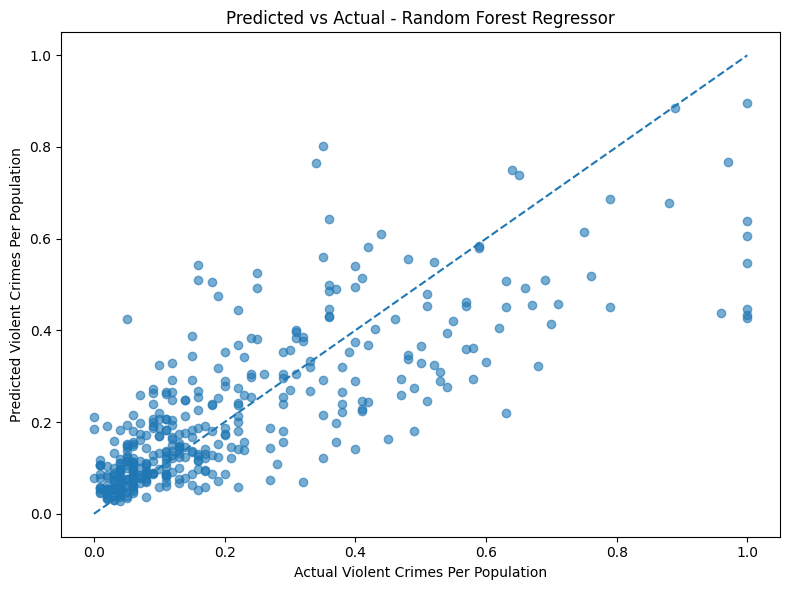

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_best_pred,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("Predicted vs Actual - Random Forest Regressor")
plt.xlabel("Actual Violent Crimes Per Population")
plt.ylabel("Predicted Violent Crimes Per Population")

plt.tight_layout()
plt.show()

Observation:
The predicted values generally increase with the actual values, showing that the Random Forest model captures the overall relationship between the input features and `ViolentCrimesPerPop`. However, several observations deviate from the ideal prediction line, indicating prediction errors for some communities.

In [49]:
rf_residuals = y_test - rf_best_pred

print("First 10 residuals:")
print(rf_residuals.head(10))

First 10 residuals:
889     0.01945
1672   -0.03100
414    -0.06985
1599   -0.00470
849    -0.02145
1658   -0.02630
926    -0.03015
1670   -0.07545
1448   -0.00615
1216   -0.07955
Name: ViolentCrimesPerPop, dtype: float64


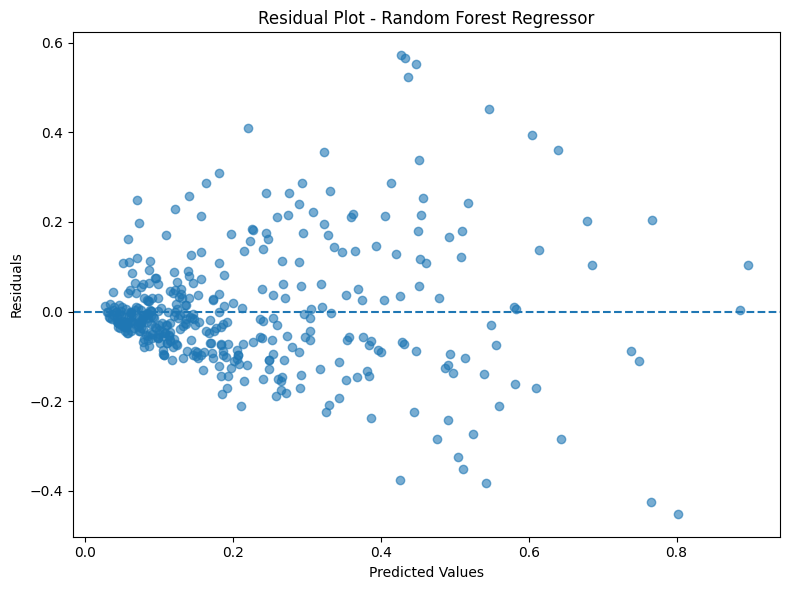

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rf_best_pred,
    rf_residuals,
    alpha=0.6
)

# Zero residual line
plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot - Random Forest Regressor")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

Observation: The residuals are distributed around the zero line, although the spread becomes larger for higher predicted values. Some relatively large positive and negative residuals are also present, indicating observations for which the model predictions differ substantially from the actual values.

In [51]:
print("===== RANDOM FOREST REGRESSOR - FINAL RESULTS =====")

print("Best Parameters:", rf_grid.best_params_)

print("\nTest Set Performance:")
print("R²   :", round(rf_best_r2, 6))
print("RMSE :", round(rf_best_rmse, 6))
print("MAE  :", round(rf_best_mae, 6))

print("\n5-Fold Cross-Validation:")
print("Mean CV R² :", round(rf_cv_scores.mean(), 6))
print("CV R² Std  :", round(rf_cv_scores.std(), 6))

===== RANDOM FOREST REGRESSOR - FINAL RESULTS =====
Best Parameters: {'n_estimators': 200}

Test Set Performance:
R²   : 0.618575
RMSE : 0.135162
MAE  : 0.092785

5-Fold Cross-Validation:
Mean CV R² : 0.646797
CV R² Std  : 0.019792
